Week 9: Backtesting Framework
Tasks:
Implement backtesting logic:


Buy if predicted return > threshold positive


Sell if predicted return < threshold negative


Calculate metrics:


Total Return, Sharpe Ratio(>1 better), Max Drawdown(% loss)
Compare to Buy-and-Hold and Random strategies.


Milestones:
Backtest results with performance chart.

Baseline comparison (Buy/Hold vs. AI strategy).

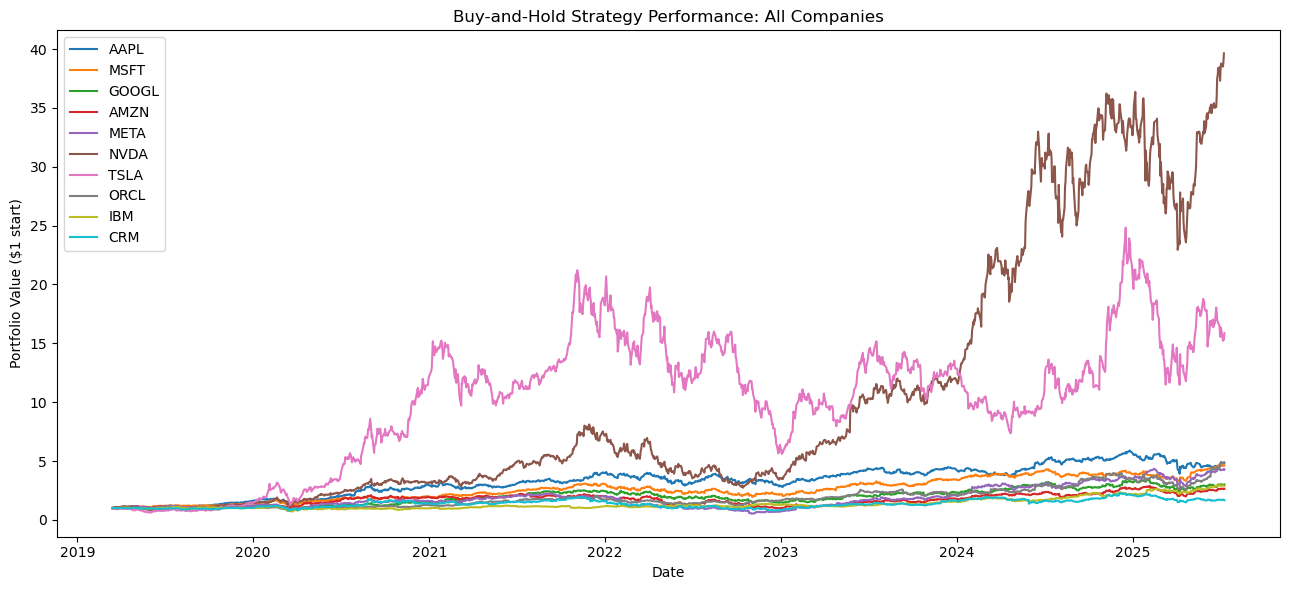

In [2]:
# Buy-and-Hold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'ORCL', 'IBM', 'CRM']
engineered_dir = Path("data/engineered")
plt.figure(figsize=(13, 6))

for ticker in tickers:
    df = pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df.dropna().reset_index(drop=True)
    df['BuyHold_Cum'] = 1.0 * np.exp(df['Return'].cumsum())
    plt.plot(df['Date'], df['BuyHold_Cum'], label=ticker)
plt.title("Buy-and-Hold Strategy Performance: All Companies")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($1 start)")
plt.legend()
plt.tight_layout()
plt.show()

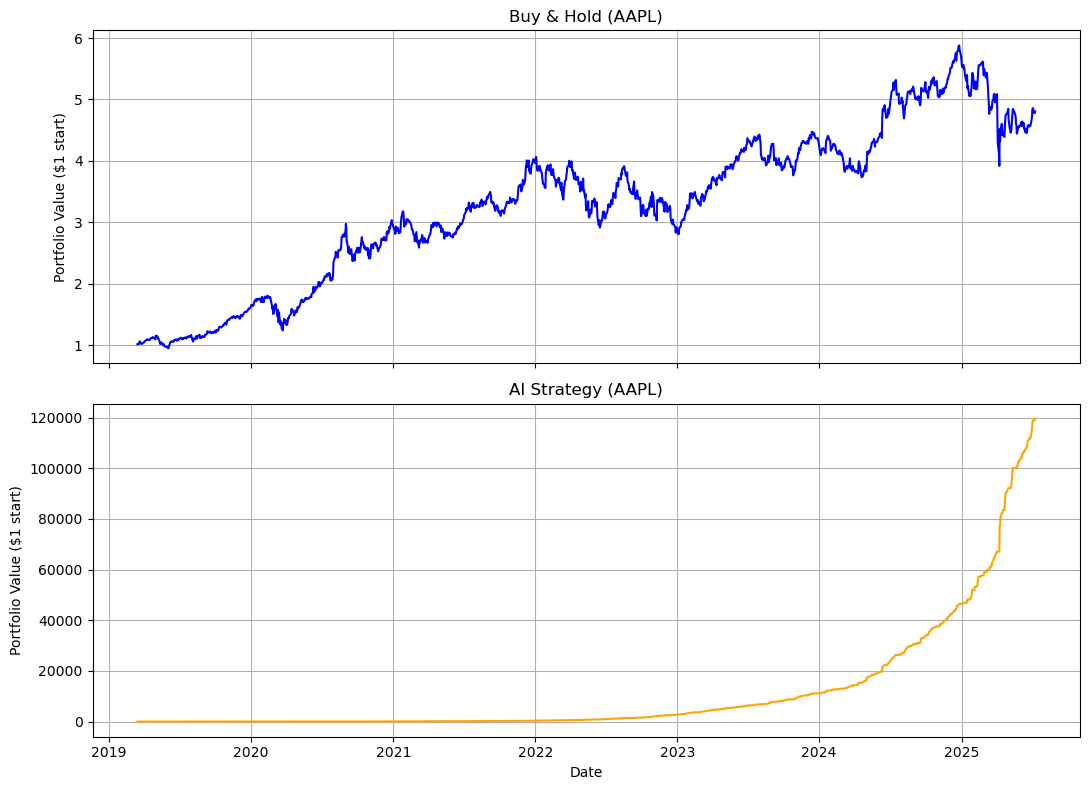

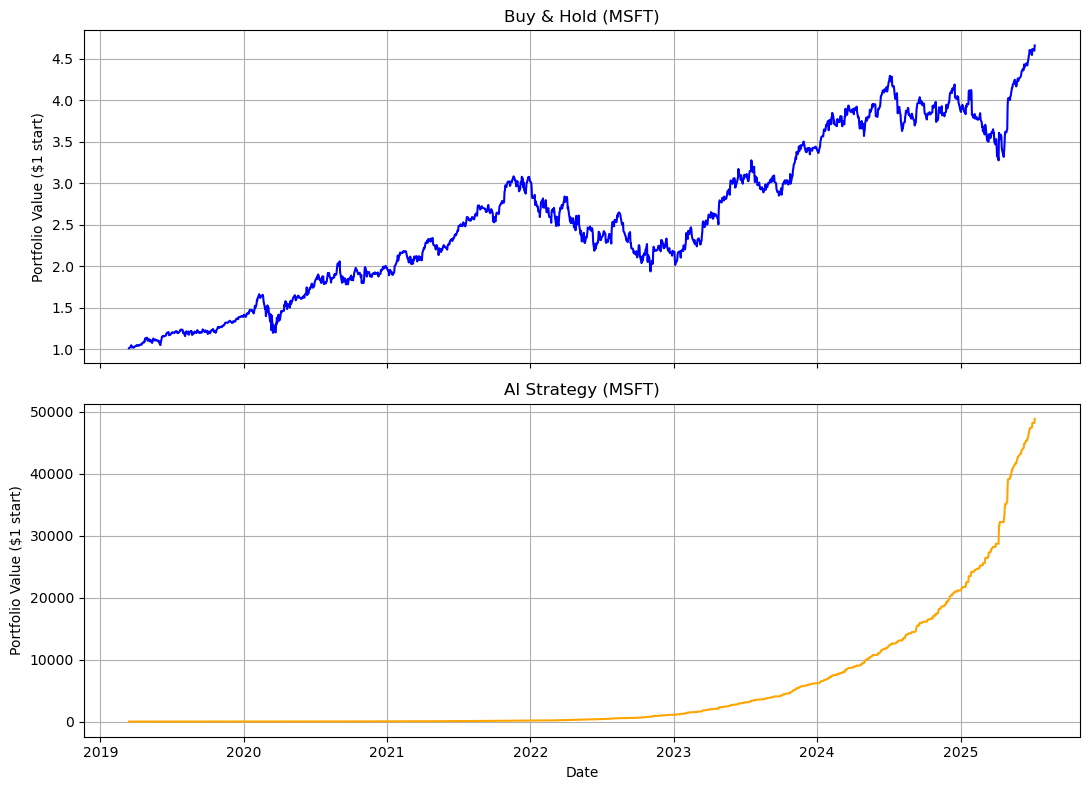

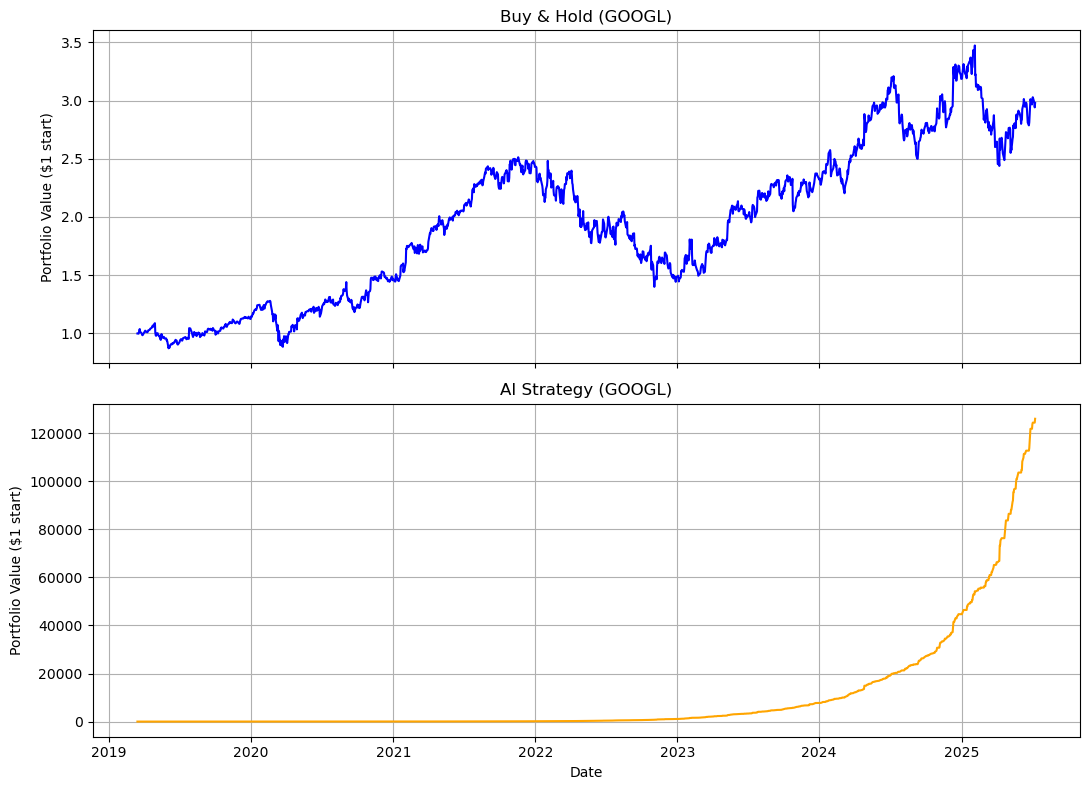

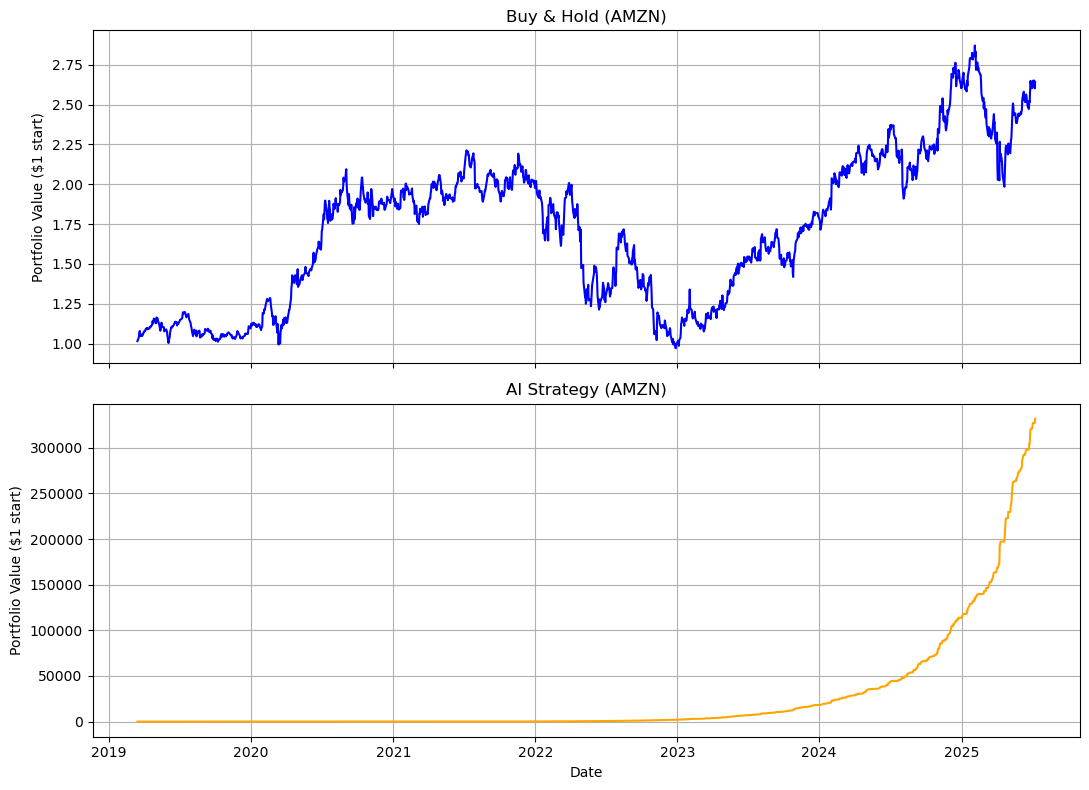

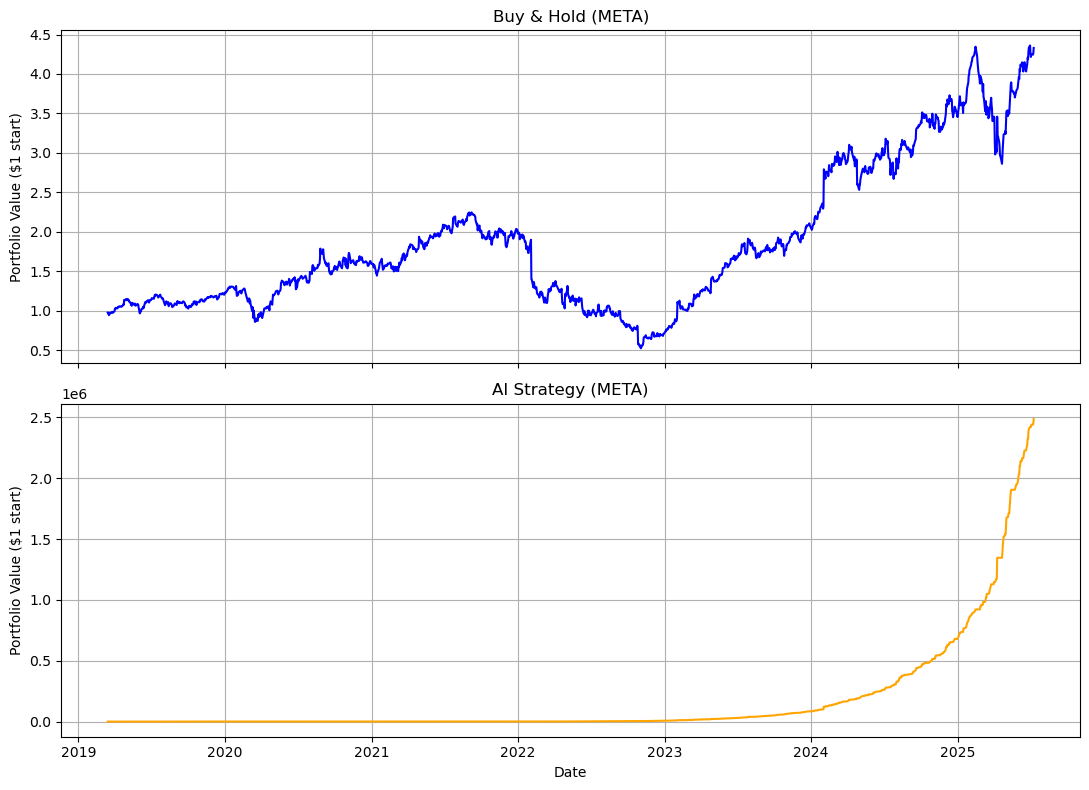

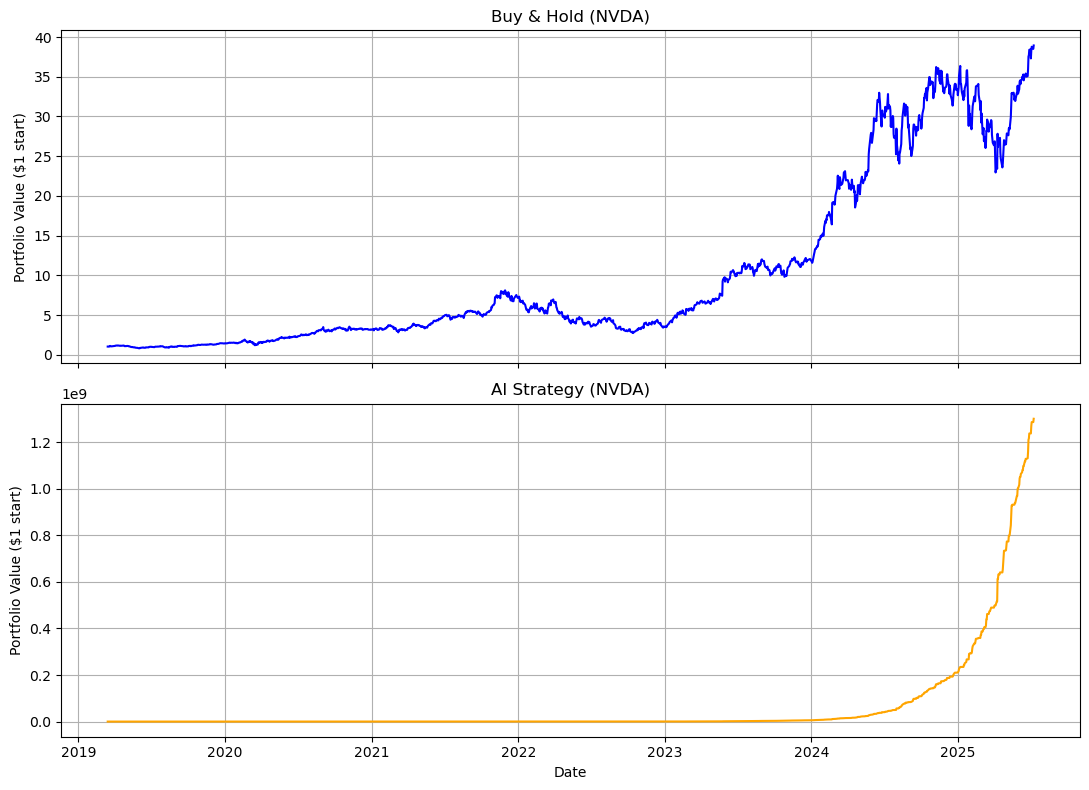

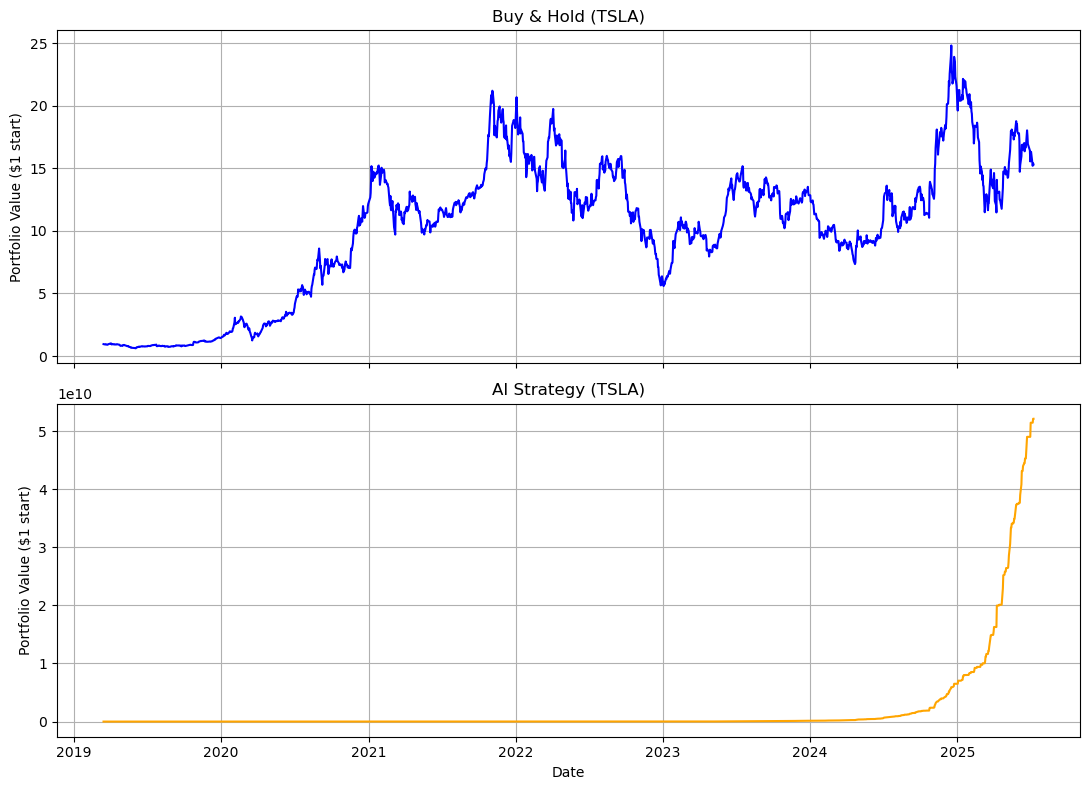

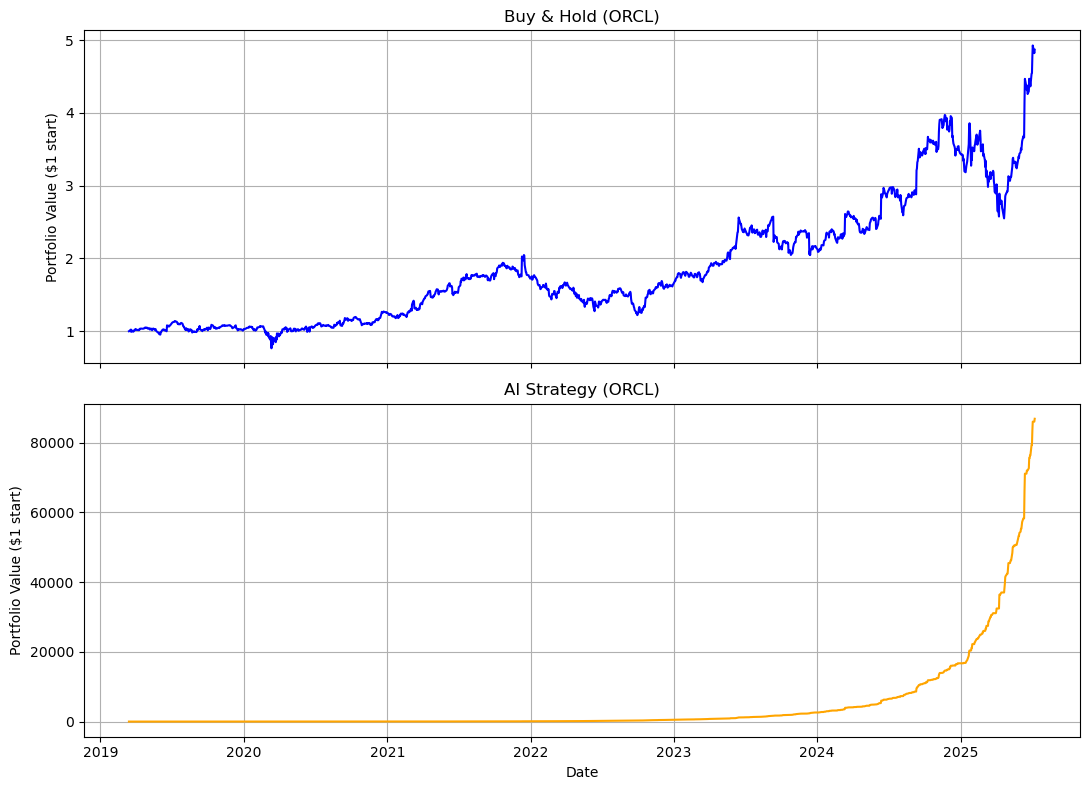

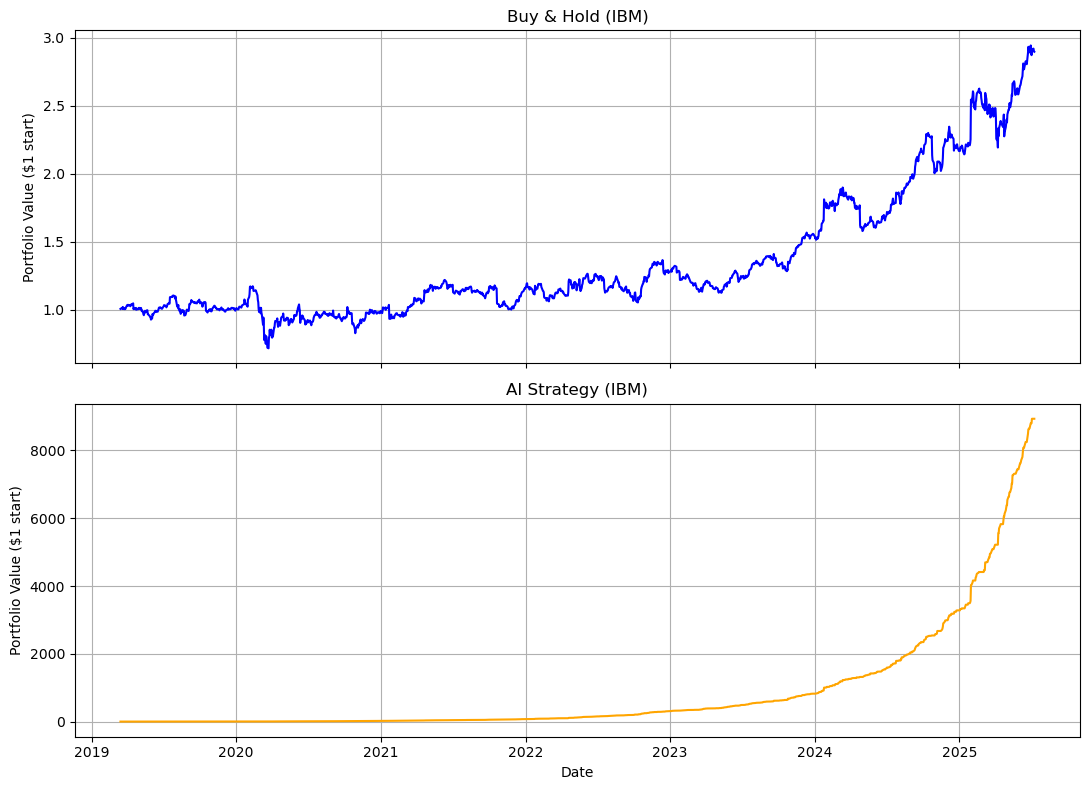

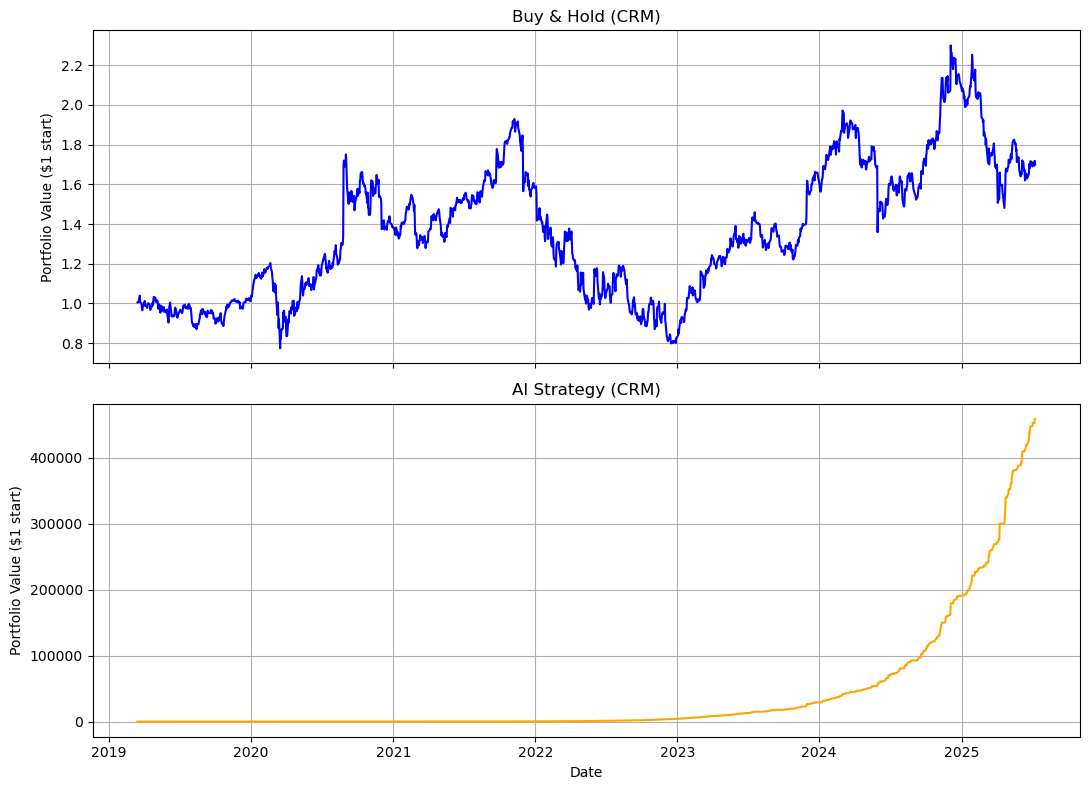

In [3]:
threshold_pos = 0.002
threshold_neg = -0.002

for ticker in tickers:
    file = f"data/processed/{ticker}_engineered_with_targets.csv"
    df = pd.read_csv(file, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    
    df['Signal'] = 0
    df.loc[df['target_next_log_return'] > threshold_pos, 'Signal'] = 1
    df.loc[df['target_next_log_return'] < threshold_neg, 'Signal'] = 0
    df['Signal'] = df['Signal'].ffill().fillna(0)
    
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df.dropna(subset=['LogReturn']).reset_index(drop=True)
    df['StrategyReturn'] = df['Signal'].shift(1, fill_value=0) * df['LogReturn']
    df['AI_Portfolio'] = 1.0 * np.exp(df['StrategyReturn'].cumsum())
    df['BuyHold']      = 1.0 * np.exp(df['LogReturn'].cumsum())

    fig, ax = plt.subplots(2, 1, figsize=(11,8), sharex=True)
    ax[0].plot(df['Date'], df['BuyHold'], color='blue')
    ax[0].set_title(f'Buy & Hold ({ticker})')
    ax[0].set_ylabel('Portfolio Value ($1 start)')
    ax[0].grid(True)
    
    ax[1].plot(df['Date'], df['AI_Portfolio'], color='orange')
    ax[1].set_title(f'AI Strategy ({ticker})')
    ax[1].set_xlabel('Date')
    ax[1].set_ylabel('Portfolio Value ($1 start)')
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()


In [5]:
# Total Return, Sharpe, Max Drawdown for both Buy & Hold and AI strategies
import pandas as pd
import numpy as np

threshold_pos = 0.002
threshold_neg = -0.002

results = {}

for ticker in tickers:
    file = f"data/processed/{ticker}_engineered_with_targets.csv"
    df = pd.read_csv(file, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
    if 'pred_next_log_return' in df.columns:
        pred = df['pred_next_log_return']
    else:
        pred = df['LogReturn'].shift(1)

    signal = np.where(pred > threshold_pos, 1,
              np.where(pred < threshold_neg, 0, 0)).astype(int)
    df['Position'] = pd.Series(signal, index=df.index).shift(1).fillna(0).astype(int)
    df['StrategyReturn'] = df['Position'] * df['LogReturn']
    df = df.dropna(subset=['LogReturn']).reset_index(drop=True)
    df['AI_Portfolio'] = np.exp(df['StrategyReturn'].cumsum())
    df['BuyHold']      = np.exp(df['LogReturn'].cumsum())

    results[ticker] = df

def sharpe_ratio(returns, risk_free=0.0):
    excess = returns - risk_free/252
    vol = excess.std()
    return (excess.mean() / vol) * np.sqrt(252) if vol != 0 else np.nan

def max_drawdown(series):
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    return drawdown.min()

summary = []
for ticker, df in results.items():
    bh, ai = df['BuyHold'], df['AI_Portfolio']
    r_bh, r_ai = df['LogReturn'], df['StrategyReturn']
    summary.append({
        "Ticker": ticker,
        "BuyHold_TotalReturn": bh.iloc[-1] / bh.iloc[0] - 1,
        "BuyHold_Sharpe": sharpe_ratio(r_bh),
        "BuyHold_MaxDrawdown": max_drawdown(bh),
        "AI_TotalReturn": ai.iloc[-1] / ai.iloc[0] - 1,
        "AI_Sharpe": sharpe_ratio(r_ai),
        "AI_MaxDrawdown": max_drawdown(ai),
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

  Ticker  BuyHold_TotalReturn  BuyHold_Sharpe  BuyHold_MaxDrawdown  \
0   AAPL             3.742006        0.789911            -0.333605   
1   MSFT             3.606796        0.837999            -0.371485   
2  GOOGL             1.985453        0.545525            -0.443201   
3   AMZN             1.599220        0.447000            -0.561453   
4   META             3.439089        0.539714            -0.767361   
5   NVDA            36.962007        1.110473            -0.663351   
6   TSLA            15.113714        0.658859            -0.736322   
7   ORCL             3.876664        0.751951            -0.403648   
8    IBM             1.883203        0.636493            -0.389801   
9    CRM             0.692118        0.222320            -0.586172   

   AI_TotalReturn  AI_Sharpe  AI_MaxDrawdown  
0        1.041449   0.561518       -0.391797  
1        0.163660   0.127672       -0.394521  
2        0.930624   0.476662       -0.411239  
3        0.888253   0.444492       -0.360

In [6]:
# Random strategy baseline
np.random.seed(42)
random_results = {}
for ticker, df in results.items():
    df = df.copy()
    n = len(df)
    df['Random_Signal'] = np.random.choice([0, 1], size=n) # Each day: randomly be long (1) or out (0), with 50% probability
    df['Random_StrategyReturn'] = df['Random_Signal'].shift(1, fill_value=0) * df['LogReturn']
    df['Random_Portfolio'] = 1.0 * np.exp(df['Random_StrategyReturn'].cumsum())
    random_results[ticker] = df

def sharpe_ratio(returns, risk_free=0):
    excess = returns - risk_free/252
    std = excess.std()
    return (excess.mean() / std) * np.sqrt(252) if std != 0 else np.nan

def max_drawdown(series):
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    return drawdown.min()

summary = []
for ticker, df in random_results.items():
    bh = df['BuyHold']
    ai = df['AI_Portfolio']
    rand = df['Random_Portfolio']
    r_bh = df['LogReturn']
    r_ai = df['StrategyReturn']
    r_rand = df['Random_StrategyReturn']
    summary.append({
        "Ticker": ticker,
        "BuyHold_TotalReturn": bh.iloc[-1] / bh.iloc[0] - 1,
        "BuyHold_Sharpe": sharpe_ratio(r_bh),
        "BuyHold_MaxDrawdown": max_drawdown(bh),
        "AI_TotalReturn": ai.iloc[-1] / ai.iloc[0] - 1,
        "AI_Sharpe": sharpe_ratio(r_ai),
        "AI_MaxDrawdown": max_drawdown(ai),
        "Random_TotalReturn": rand.iloc[-1] / rand.iloc[0] - 1,
        "Random_Sharpe": sharpe_ratio(r_rand),
        "Random_MaxDrawdown": max_drawdown(rand)
    })

summary_df = pd.DataFrame(summary)

for col in ["BuyHold_TotalReturn", "AI_TotalReturn", "Random_TotalReturn"]:
    if pd.api.types.is_numeric_dtype(summary_df[col]):
        summary_df[col] = summary_df[col].map(lambda x: f"{x:.2%}")

for col in ["BuyHold_Sharpe", "AI_Sharpe", "Random_Sharpe"]:
    if pd.api.types.is_numeric_dtype(summary_df[col]):
        summary_df[col] = summary_df[col].map(lambda x: f"{x:.2f}")

for col in ["BuyHold_MaxDrawdown", "AI_MaxDrawdown", "Random_MaxDrawdown"]:
    if pd.api.types.is_numeric_dtype(summary_df[col]):
        summary_df[col] = summary_df[col].map(lambda x: f"{x:.2%}")

print(summary_df)

summary_df.to_csv("backtest_metrics_with_random.csv", index=False)


  Ticker BuyHold_TotalReturn BuyHold_Sharpe BuyHold_MaxDrawdown  \
0   AAPL             374.20%           0.79             -33.36%   
1   MSFT             360.68%           0.84             -37.15%   
2  GOOGL             198.55%           0.55             -44.32%   
3   AMZN             159.92%           0.45             -56.15%   
4   META             343.91%           0.54             -76.74%   
5   NVDA            3696.20%           1.11             -66.34%   
6   TSLA            1511.37%           0.66             -73.63%   
7   ORCL             387.67%           0.75             -40.36%   
8    IBM             188.32%           0.64             -38.98%   
9    CRM              69.21%           0.22             -58.62%   

  AI_TotalReturn AI_Sharpe AI_MaxDrawdown Random_TotalReturn Random_Sharpe  \
0        104.14%      0.56        -39.18%             55.22%          0.33   
1         16.37%      0.13        -39.45%            127.59%          0.61   
2         93.06%      0.48  

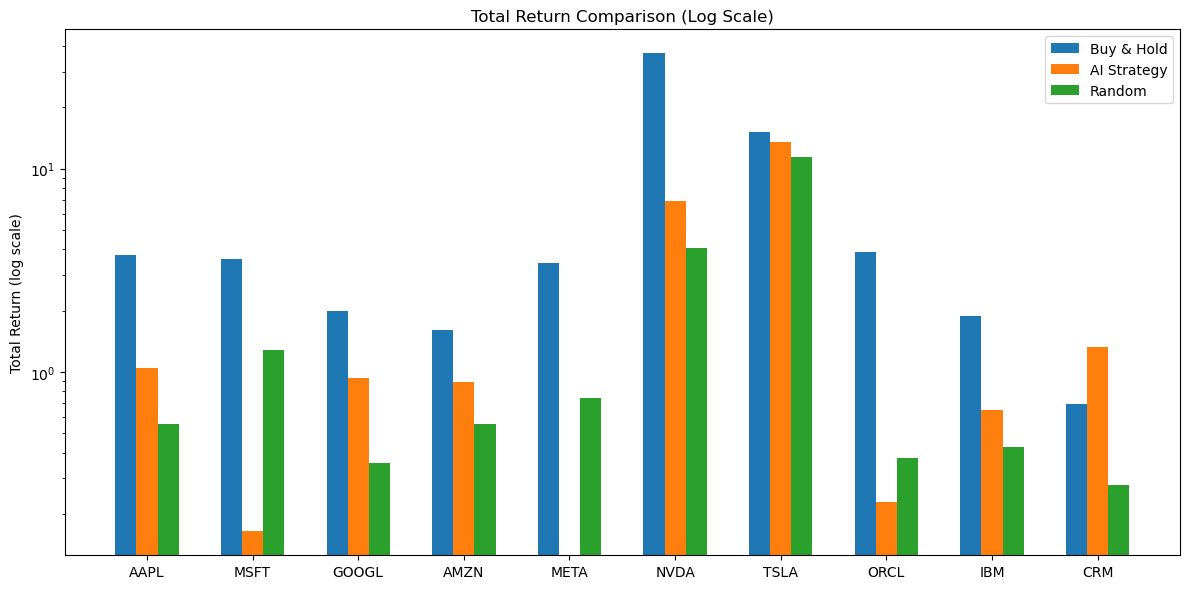

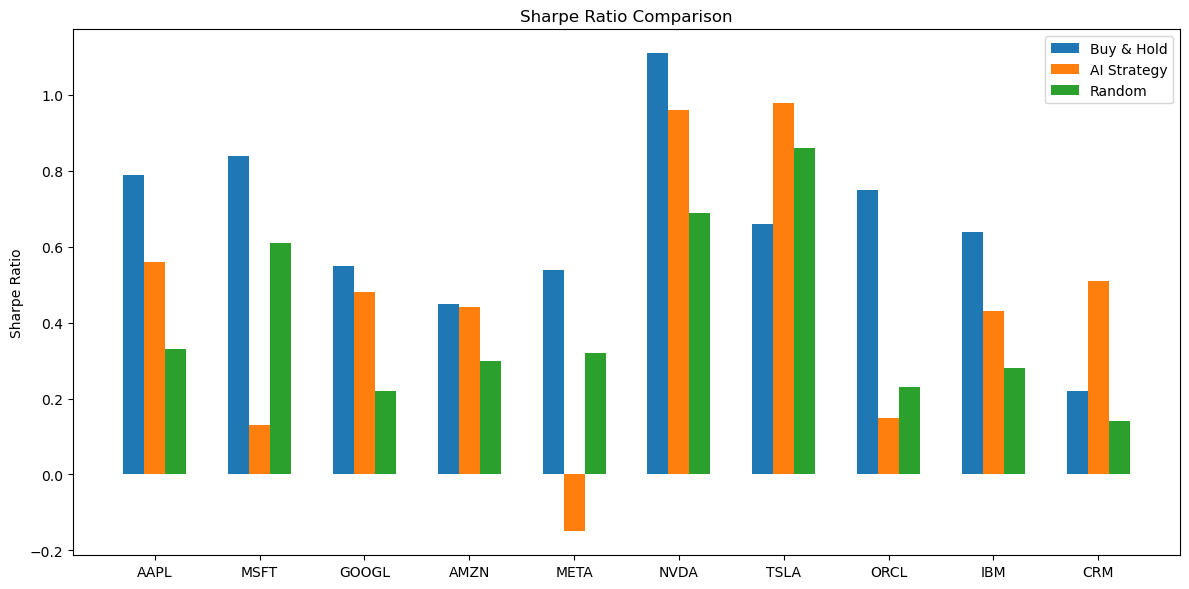

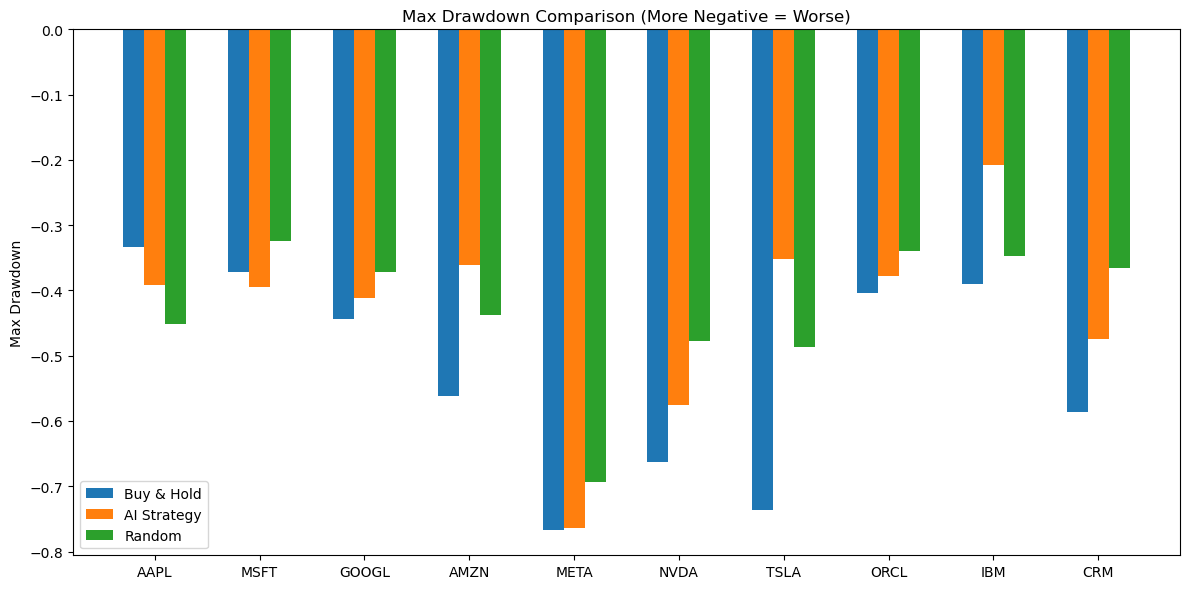

In [7]:
def pct2float(s):
    if isinstance(s, str) and '%' in s:
        return float(s.replace('%','')) / 100
    return float(s)
df = summary_df.copy()

for col in ["BuyHold_TotalReturn", "AI_TotalReturn", "Random_TotalReturn",
            "BuyHold_MaxDrawdown", "AI_MaxDrawdown", "Random_MaxDrawdown"]:
    df[col] = df[col].apply(pct2float)

for col in ["BuyHold_Sharpe", "AI_Sharpe", "Random_Sharpe"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Total return
plt.figure(figsize=(12,6))
width = 0.2
x = np.arange(len(df["Ticker"]))
plt.bar(x-width, df["BuyHold_TotalReturn"], width, label='Buy & Hold')
plt.bar(x,        df["AI_TotalReturn"], width, label='AI Strategy')
plt.bar(x+width,  df["Random_TotalReturn"], width, label='Random')
plt.xticks(x, df["Ticker"])
plt.ylabel("Total Return (log scale)")
plt.title("Total Return Comparison (Log Scale)")
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

# Sharpe ratio
plt.figure(figsize=(12,6))
plt.bar(x-width, df["BuyHold_Sharpe"], width, label='Buy & Hold')
plt.bar(x,        df["AI_Sharpe"], width, label='AI Strategy')
plt.bar(x+width,  df["Random_Sharpe"], width, label='Random')
plt.xticks(x, df["Ticker"])
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Max drawdown
plt.figure(figsize=(12,6))
plt.bar(x-width, df["BuyHold_MaxDrawdown"], width, label='Buy & Hold')
plt.bar(x,        df["AI_MaxDrawdown"], width, label='AI Strategy')
plt.bar(x+width,  df["Random_MaxDrawdown"], width, label='Random')
plt.xticks(x, df["Ticker"])
plt.ylabel("Max Drawdown")
plt.title("Max Drawdown Comparison (More Negative = Worse)")
plt.legend()
plt.tight_layout()
plt.show()